# 🍷 Wine Quality Analysis & Classification

This project analyzes the **Red Wine Quality dataset** to understand the relationship between physicochemical properties and wine quality.

### Objectives

* Explore the distribution of wine quality scores.
* Analyze the distribution of important chemical properties.
* Identify relationships between physicochemical features and wine quality.
* Handle the imbalanced quality categories.
* Build and compare multiple machine learning classification models.
* Identify the features that contribute most to model predictions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("winequality-red.csv")

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2    

In [ ]:
print("\nQuality Score Distribution:")
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

print("\nQuality Score Percentages:")
quality_percentages = (
    df["quality"].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(quality_percentages)


Quality Score Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Quality Score Percentages:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


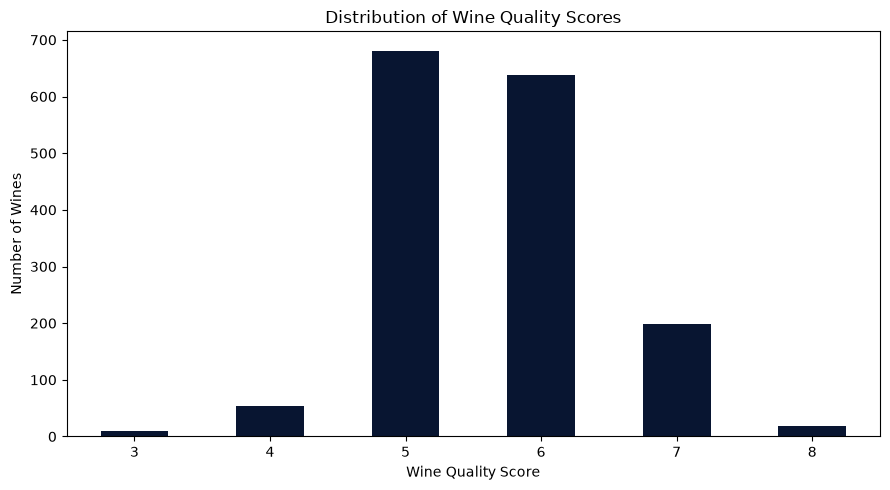

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique()),
    width=0.5,
    color="#011338"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

## 📊 Wine Quality Score Distribution

### Observation

* The wine quality scores range from **3 to 8**.
* Quality **5** is the most frequent score, with **681 wines (42.59%)**.
* Quality **6** follows with **638 wines (39.90%)**.
* Very few wines have quality scores of **3 or 8**.

### Analysis

* The majority of wines fall within the **medium-quality range**.
* The distribution is not balanced across all quality scores.
* The limited number of observations for extreme quality scores may make them more difficult to analyze and predict.

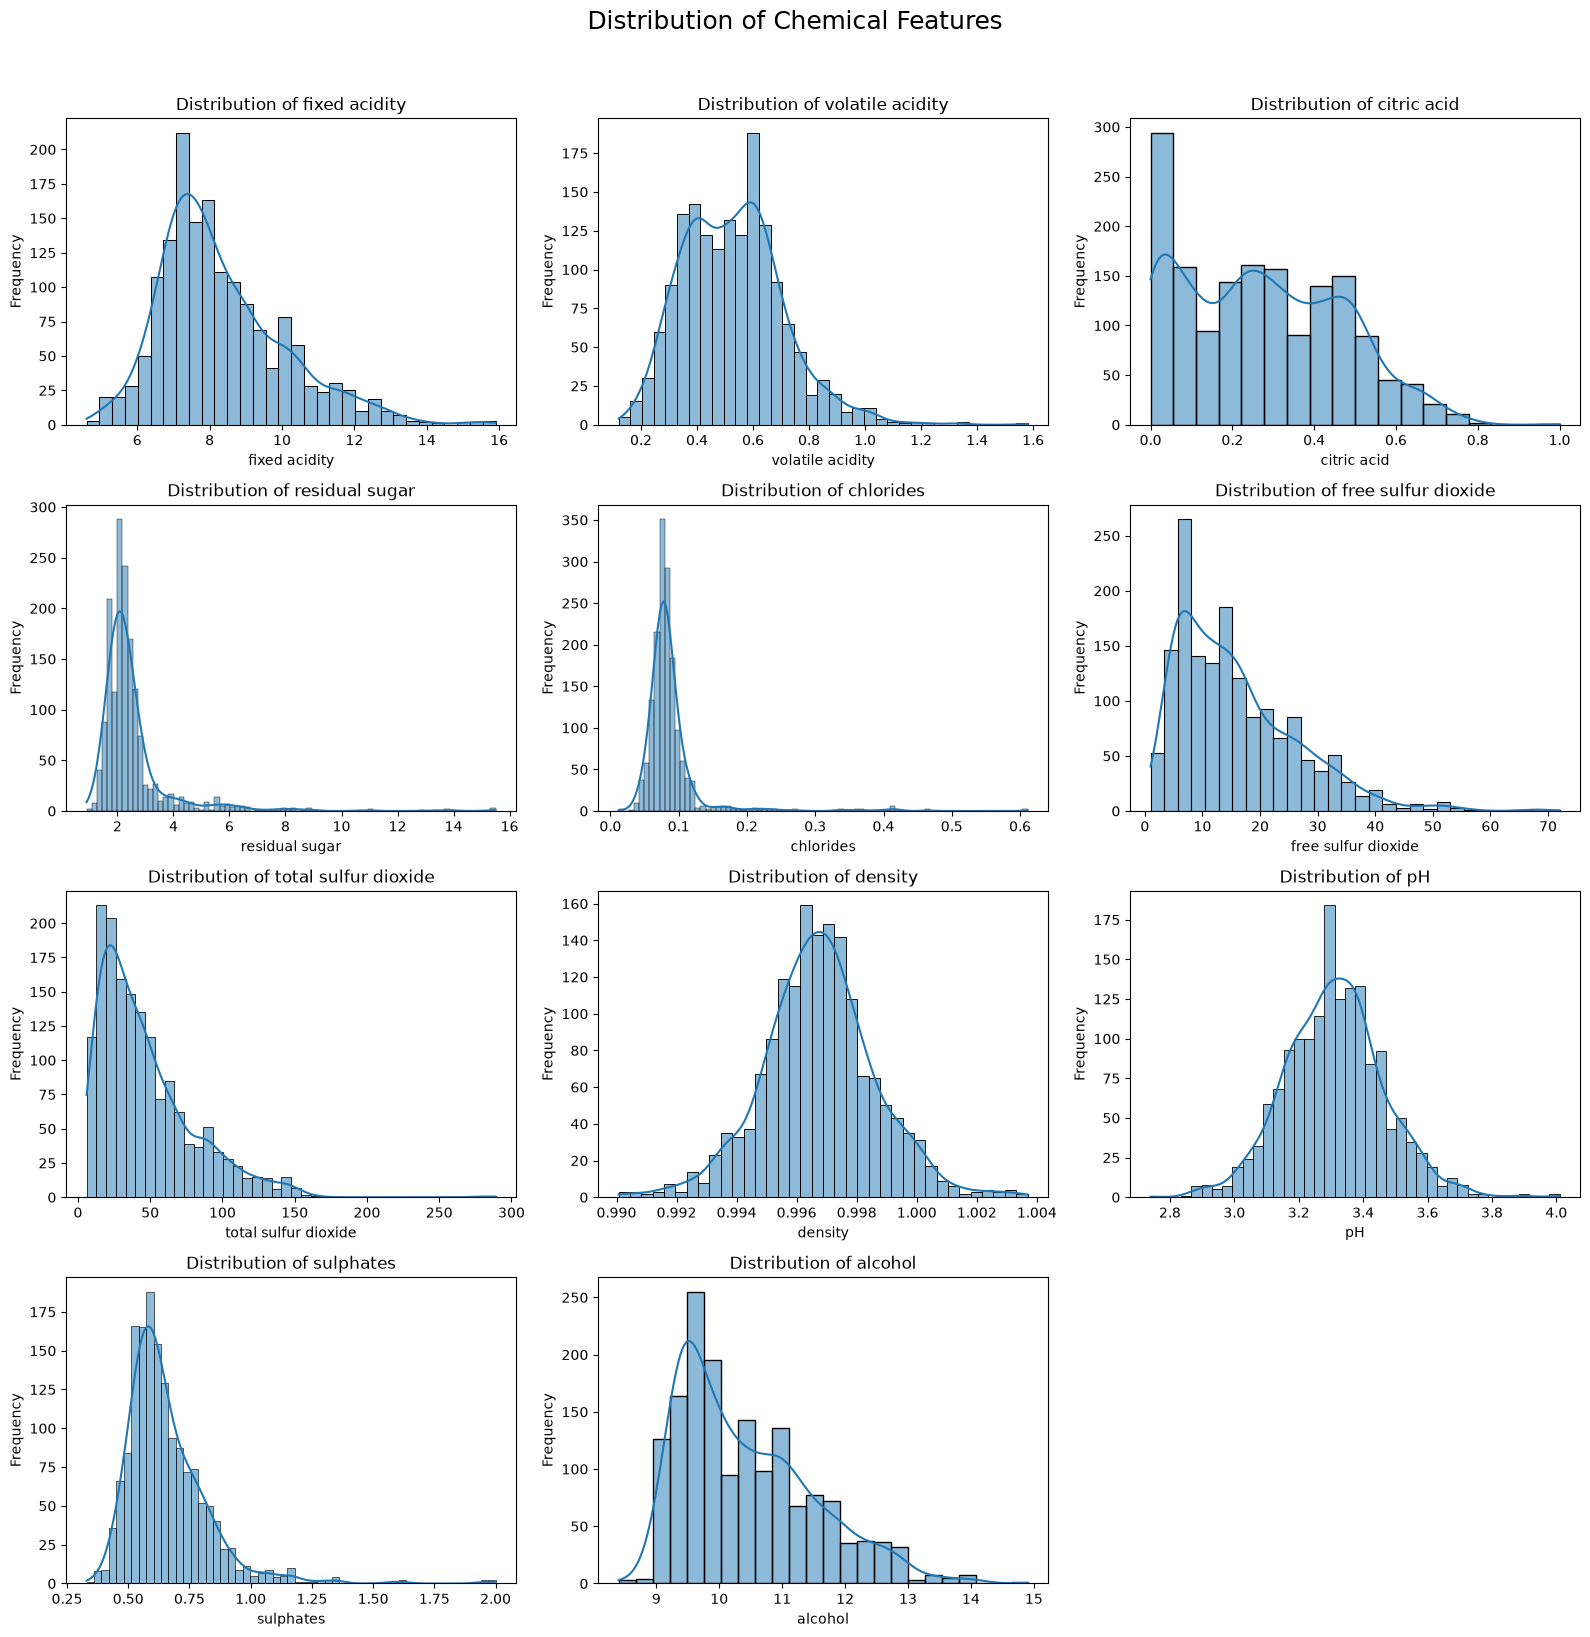

In [ ]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# Create one figure for all feature distributions
fig, axes = plt.subplots(4, 3, figsize=(16, 16))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.histplot(
        df[feature],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide unused subplot
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Distribution of Chemical Features",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

## 📈 Distribution of Chemical Features

### Observation

* The dataset contains multiple physicochemical properties describing each wine.
* The features have **different ranges, scales, and distributions**.
* Some variables show noticeable skewness and variation across wine samples.
* Features such as alcohol, acidity, sulphates, and sulfur dioxide show substantial differences between observations.

### Analysis

* The variation in chemical properties indicates that wines in the dataset have different compositions.
* Since the features are measured on different scales, direct comparison between their numerical values is not always meaningful.
* Understanding these distributions is important before applying machine learning algorithms.

### Recommendation

* Examine feature distributions and potential outliers before modeling.
* Apply **feature scaling** for algorithms that are sensitive to feature magnitude.
* Retain the original feature distributions during EDA to better understand the dataset.


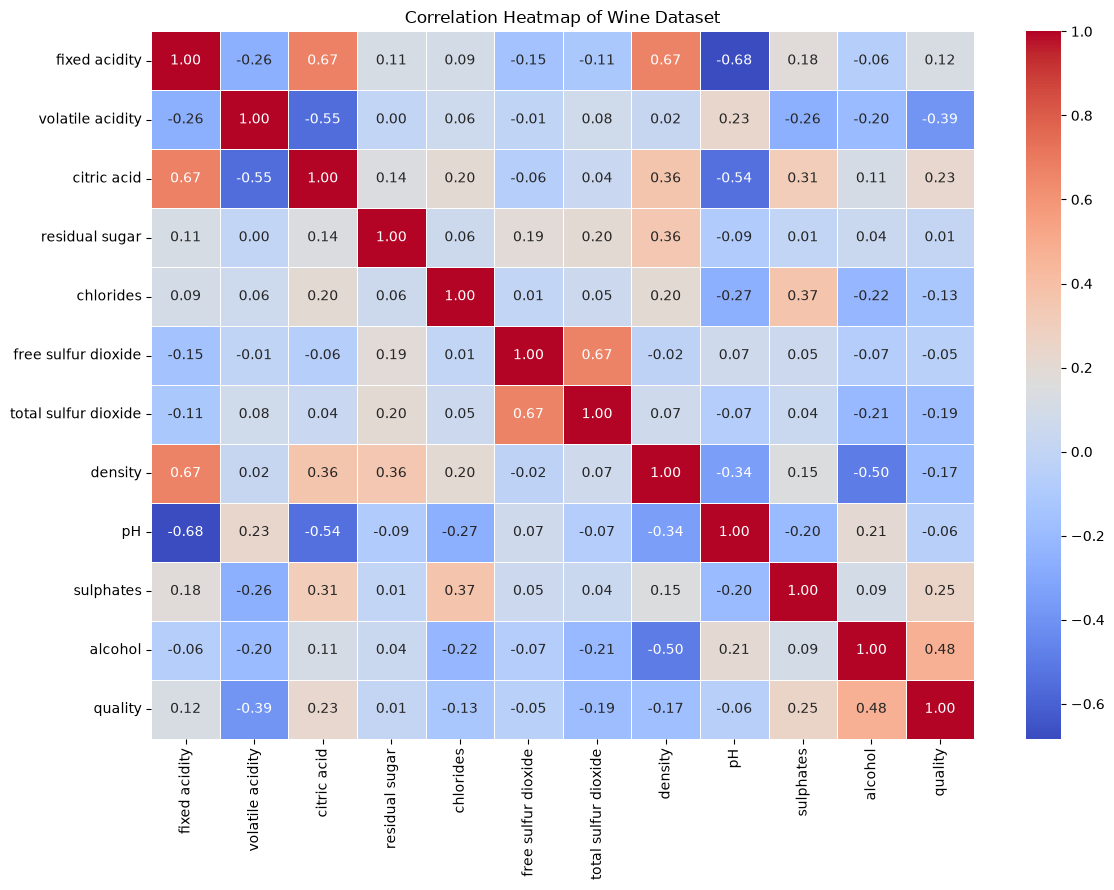

In [ ]:
plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Dataset")
plt.tight_layout()
plt.show()


## 🔥 Correlation Analysis

### Observation

* **Alcohol** shows the strongest positive correlation with wine quality.
* **Volatile acidity** shows the strongest negative correlation with quality.
* **Sulphates** and **citric acid** also show positive relationships with quality.
* Some features have relatively weak correlations with the target variable.

### Analysis

* The correlation results indicate that different chemical properties have different levels of association with wine quality.
* Alcohol appears to be an important variable associated with higher quality scores.
* Higher volatile acidity is associated with lower quality scores in this dataset.
* Correlation measures **association and does not establish causation**.

### Recommendation

* Consider strongly associated variables during feature analysis and model development.
* Use correlation analysis together with machine learning feature importance rather than relying on correlation alone.
* Investigate combinations of features because individual correlation values may not capture complex relationships.


In [ ]:
print("\nCorrelation of Features with Quality:")

quality_correlation = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

print(quality_correlation)


Correlation of Features with Quality:
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [ ]:
print("\nOriginal Quality Class Counts:")
print(quality_counts)

print("\nOriginal Quality Class Percentages:")
print(quality_percentages)


Original Quality Class Counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Original Quality Class Percentages:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64

Class Imbalance Observation:

The dataset is highly imbalanced.

Quality scores 5 and 6 contain most of the observations,
while quality scores 3 and 8 contain very few observations.

This imbalance can affect machine learning models because
the model may become biased toward the majority classes.

A model could achieve high overall accuracy by predicting
the majority classes frequently while performing poorly
on rare quality classes.



In [ ]:
def quality_category(quality):

    if quality <= 4:
        return "Low"

    elif quality <= 6:
        return "Medium"

    else:
        return "High"


# Create new target column
df["quality_category"] = df["quality"].apply(quality_category)


print("\nOriginal Quality vs New Category:")

print(
    df[["quality", "quality_category"]]
    .head(15)
)
print("\nNew Class Distribution:")

category_counts = df["quality_category"].value_counts()

print(category_counts)


print("\nNew Class Percentages:")

category_percentages = (
    df["quality_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentages)


Original Quality vs New Category:
    quality quality_category
0         5           Medium
1         5           Medium
2         5           Medium
3         6           Medium
4         5           Medium
5         5           Medium
6         5           Medium
7         7             High
8         7             High
9         5           Medium
10        5           Medium
11        5           Medium
12        5           Medium
13        5           Medium
14        5           Medium

New Class Distribution:
quality_category
Medium    1319
High       217
Low         63
Name: count, dtype: int64

New Class Percentages:
quality_category
Medium    82.49
High      13.57
Low        3.94
Name: proportion, dtype: float64


In [ ]:
X = df[features]

# Target
y = df["quality_category"]


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(1279, 11)

Testing Data Shape:
(320, 11)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

sgd = SGDClassifier(
    loss="log_loss",
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

sgd.fit(X_train_scaled, y_train)

sgd_predictions = sgd.predict(X_test_scaled)

svc = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svc.fit(X_train_scaled, y_train)

svc_predictions = svc.predict(X_test_scaled)


print("\nAll three models trained successfully.")


All three models trained successfully.



------------------------------------------------------------
Random Forest
------------------------------------------------------------

Accuracy: 0.8344
Accuracy: 83.44%

Classification Report:
              precision    recall  f1-score   support

         Low       0.25      0.08      0.12        13
      Medium       0.91      0.89      0.90       264
        High       0.54      0.72      0.62        43

    accuracy                           0.83       320
   macro avg       0.57      0.56      0.55       320
weighted avg       0.83      0.83      0.83       320


Confusion Matrix:
[[  1  12   0]
 [  3 235  26]
 [  0  12  31]]


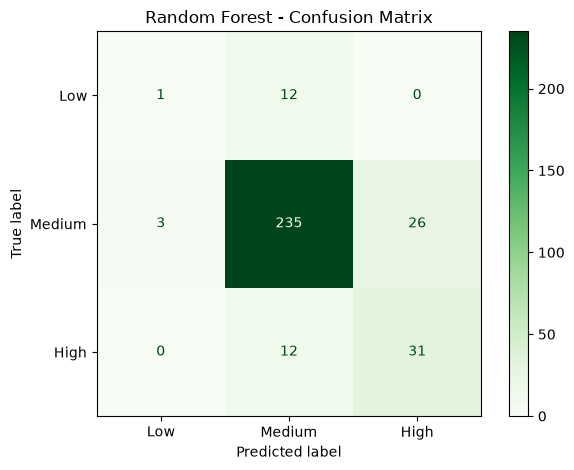


------------------------------------------------------------
SGD Classifier
------------------------------------------------------------

Accuracy: 0.7031
Accuracy: 70.31%

Classification Report:
              precision    recall  f1-score   support

         Low       0.06      0.23      0.09        13
      Medium       0.89      0.76      0.82       264
        High       0.49      0.49      0.49        43

    accuracy                           0.70       320
   macro avg       0.48      0.49      0.47       320
weighted avg       0.80      0.70      0.75       320


Confusion Matrix:
[[  3  10   0]
 [ 41 201  22]
 [  8  14  21]]


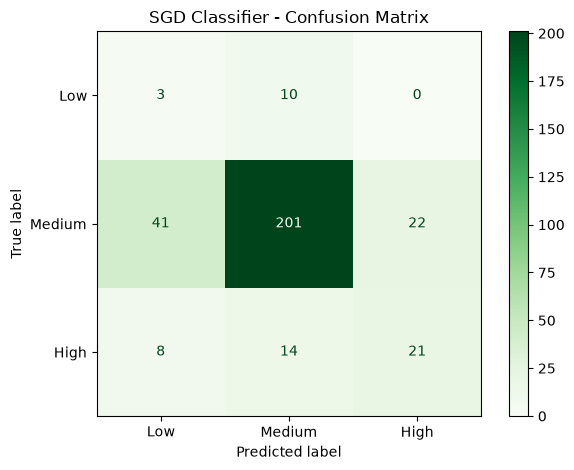


------------------------------------------------------------
Support Vector Classifier
------------------------------------------------------------

Accuracy: 0.7094
Accuracy: 70.94%

Classification Report:
              precision    recall  f1-score   support

         Low       0.10      0.23      0.14        13
      Medium       0.92      0.73      0.81       264
        High       0.40      0.74      0.52        43

    accuracy                           0.71       320
   macro avg       0.47      0.57      0.49       320
weighted avg       0.82      0.71      0.74       320


Confusion Matrix:
[[  3   9   1]
 [ 24 192  48]
 [  3   8  32]]


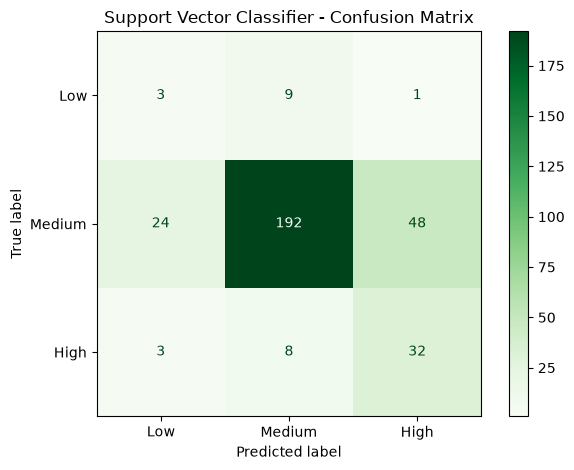

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    print("\n" + "-" * 60)
    print(model_name)
    print("-" * 60)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Accuracy: {accuracy * 100:.2f}%")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=["Low", "Medium", "High"],
            zero_division=0
        )
    )
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["Low", "Medium", "High"]
    )

    print("\nConfusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "Medium", "High"]
    )

    disp.plot(cmap="Greens")

    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return accuracy

# Evaluate Random Forest
rf_accuracy = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)


# Evaluate SGD
sgd_accuracy = evaluate_model(
    "SGD Classifier",
    y_test,
    sgd_predictions
)


# Evaluate SVC
svc_accuracy = evaluate_model(
    "Support Vector Classifier",
    y_test,
    svc_predictions
)

## 🤖 Model Classification Analysis

### Observation

* **Random Forest** achieved the highest accuracy at **83.44%**, followed by **SVC at 70.94%** and **SGD Classifier at 70.31%**.
* All three models performed better on the **Medium-quality** class, while the minority classes had more classification errors.
* Random Forest showed stronger overall classification performance compared with the other two models.

### Analysis

* Random Forest can capture **nonlinear relationships** between physicochemical features and wine-quality categories, which may contribute to its higher accuracy.
* SGD provides a **linear baseline**, while SVC can model more complex decision boundaries.
* The **class imbalance**, particularly the small number of Low-quality samples, makes minority-class classification more challenging.
* Therefore, accuracy alone does not fully represent the performance of the models across all quality categories.

### Recommendation

* Compare all three models using **precision, recall, and F1-score** in addition to accuracy.
* Focus on improving **minority-class performance** through class weighting and hyperparameter tuning.
* Use **feature importance and further feature engineering** to investigate whether model performance can be improved.


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                 Feature  Importance
1       volatile acidity    0.159393
10               alcohol    0.141885
9              sulphates    0.132826
2            citric acid    0.100934
6   total sulfur dioxide    0.080007
4              chlorides    0.073992
8                     pH    0.072198
5    free sulfur dioxide    0.061822
7                density    0.060932
0          fixed acidity    0.060877
3         residual sugar    0.055136


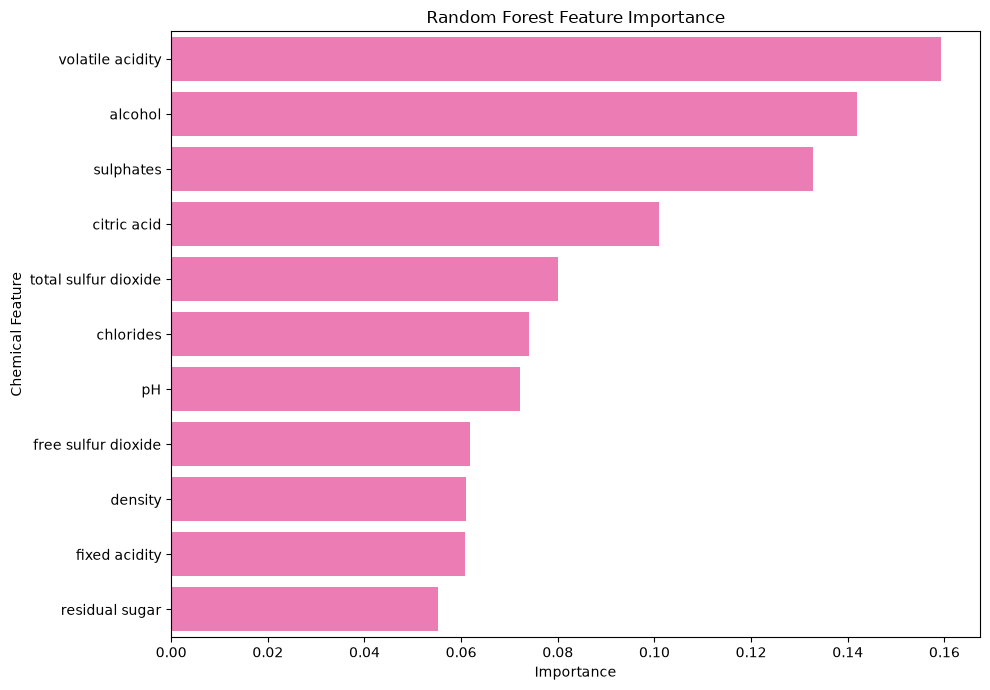

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color="hotpink"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Chemical Feature")

plt.tight_layout()
plt.show()

## 🌟 Random Forest Feature Importance

### Observation

* **Volatile acidity** has the highest feature importance in the Random Forest model.
* **Alcohol** is another highly influential feature.
* **Sulphates** and **citric acid** also contribute substantially to the model.
* Other physicochemical variables have comparatively lower importance.

### Analysis

* The feature-importance results indicate which variables the Random Forest relies on most when making predictions.
* The results are broadly useful for understanding the model's decision-making process.
* Feature importance represents **predictive contribution within the model**, rather than proving that a feature directly causes wine quality.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],

    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})


comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
).round(2)


comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
    ).reset_index(drop=True)


print("\nModel Performance:")
print(comparison)


Model Performance:
            Model  Accuracy  Accuracy (%)
0   Random Forest  0.834375         83.44
1             SVC  0.709375         70.94
2  SGD Classifier  0.703125         70.31


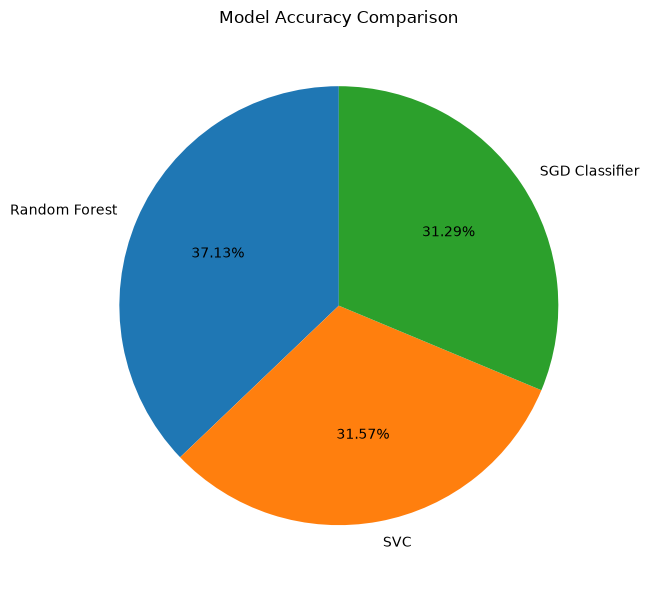

In [ ]:
plt.figure(figsize=(3, 3))

plt.pie(
    comparison["Accuracy"],
    labels=comparison["Model"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Model Accuracy Comparison")

plt.tight_layout()
plt.show()

## 📊 Model Performance Comparison

### Observation

* Random Forest achieved **83.44% accuracy**.
* SVC achieved **70.94% accuracy**.
* SGD Classifier achieved **70.31% accuracy**.
* The three models show noticeable differences in test-set accuracy.

### Analysis

* The models capture relationships in the dataset differently.
* Random Forest provides higher overall accuracy on this test split.
* However, accuracy alone may not fully reflect performance because the quality categories are imbalanced.
* Minority-class precision, recall, and F1-score should therefore be considered alongside overall accuracy.

### Recommendation

* Report **accuracy, precision, recall, and F1-score** together when presenting the final model results.
* Use the confusion matrix to understand which quality categories are most difficult to classify.
* Further improve the models through **hyperparameter tuning and class-imbalance techniques**.
